In [2]:
# ===============================
# DECISION TREE REGRESSOR
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("../data/linearregression.csv")


# 2. Features and target
X = df.drop("price_k", axis=1)
y = df["price_k"]

# 3. Train/Validation/Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

# 4. Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# 5. Handle missing values
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)
X_val_num   = pd.DataFrame(num_imputer.transform(X_val[numeric_cols]), columns=numeric_cols, index=X_val.index)
X_test_num  = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[categorical_cols]), columns=categorical_cols, index=X_train.index)
X_val_cat   = pd.DataFrame(cat_imputer.transform(X_val[categorical_cols]), columns=categorical_cols, index=X_val.index)
X_test_cat  = pd.DataFrame(cat_imputer.transform(X_test[categorical_cols]), columns=categorical_cols, index=X_test.index)

# 6. Encode categorical features
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_enc = pd.DataFrame(encoder.fit_transform(X_train_cat), columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
X_val_cat_enc   = pd.DataFrame(encoder.transform(X_val_cat), columns=encoder.get_feature_names_out(categorical_cols), index=X_val.index)
X_test_cat_enc  = pd.DataFrame(encoder.transform(X_test_cat), columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)

# 7. Combine numeric + encoded categorical
X_train_final = pd.concat([X_train_num, X_train_cat_enc], axis=1)
X_val_final   = pd.concat([X_val_num, X_val_cat_enc], axis=1)
X_test_final  = pd.concat([X_test_num, X_test_cat_enc], axis=1)

print("Final shapes after encoding:")
print("X_train_final:", X_train_final.shape)
print("X_val_final  :", X_val_final.shape)
print("X_test_final :", X_test_final.shape)

# 8. Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# 9. Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=10,       
    cv=10,            
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True
)

# 10. Fit on training data
random_search.fit(X_train_final, y_train)

best_dt = random_search.best_estimator_
print("\nBest hyperparameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

# 11. Predictions
y_train_pred = best_dt.predict(X_train_final)
y_val_pred   = best_dt.predict(X_val_final)
y_test_pred  = best_dt.predict(X_test_final)

# 12. Evaluation
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} Results")
    print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.4f}")



Shapes:
X_train: (7000, 7)
X_val  : (1500, 7)
X_test : (1500, 7)
Numeric columns: ['square_feet', 'num_bedrooms', 'num_bathrooms', 'lot_size', 'year_built']
Categorical columns: ['has_garage', 'neighborhood']
Final shapes after encoding:
X_train_final: (7000, 11)
X_val_final  : (1500, 11)
X_test_final : (1500, 11)
Fitting 10 folds for each of 10 candidates, totalling 100 fits

Best hyperparameters: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5}
Best CV R²: 0.8010982671659258


c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
31 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.p

In [3]:
evaluate(y_train, y_train_pred, "TRAIN")


TRAIN Results
MAE: 15.461, RMSE: 19.387, R²: 0.8190


In [4]:
evaluate(y_val, y_val_pred, "VALIDATION")


VALIDATION Results
MAE: 16.591, RMSE: 20.545, R²: 0.7947


In [5]:
evaluate(y_test, y_test_pred, "TEST")


TEST Results
MAE: 15.928, RMSE: 19.981, R²: 0.8095



Feature Importance (top 10):
           feature  importance
0      square_feet    0.932529
1     num_bedrooms    0.031635
7   neighborhood_A    0.015035
10  neighborhood_D    0.013281
5    has_garage_No    0.004553
3         lot_size    0.002967
2    num_bathrooms    0.000000
4       year_built    0.000000
6   has_garage_Yes    0.000000
8   neighborhood_B    0.000000


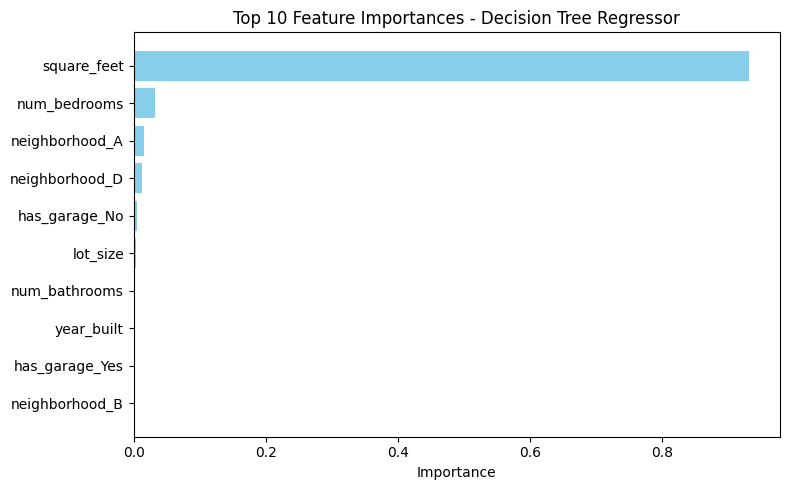

In [6]:
# 13. Feature Importance
feature_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": best_dt.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance (top 10):")
print(feature_importance.head(10))

# -----------------------------------------
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Decision Tree Regressor")
plt.tight_layout()
plt.show()